In [1]:
TASK = "figure_recreation_lohoff-2e"

In [2]:
import os
import shutil
import sys
from functools import partial
from pathlib import Path
from queue import Queue

from langchain_core.messages import HumanMessage
from openai import RateLimitError

sys.path.append(str(Path.cwd().parent / "src"))

### configure logging
from config import DATA_DIR
from notebook_utils import tee_output
log_path = Path.cwd() / f"outputs/{TASK}/transcript.log"
log_path.parent.mkdir(parents=True, exist_ok=True)
log_path.write_text("")
tee = partial(tee_output, path=log_path)

### reset data directory
from notebook_utils import _reset_data_directories
_reset_data_directories()


### Task

In [3]:
### Task Files

data_src_dir = Path.cwd() / "data"
shutil.copy(data_src_dir / "dataset_lohoff_et_al_seqfish.h5ad", DATA_DIR / "dataset/") # dataset
shutil.copy(data_src_dir / "reference_lohoff-2e.png", DATA_DIR / "uploads/")           # reference image
shutil.copy(data_src_dir / "instructions_lohoff-2e.md", DATA_DIR / "uploads/")         # methods for analysis
shutil.copy(data_src_dir / "colormap.yaml", DATA_DIR / "uploads/")                     # colormap for consistency between panels
                                                                                       # colormap is generated by TissueAgent given the figure legend and dataset
print("Files present in DATA_DIR:", end="\n - ")
files = [str(f.relative_to(DATA_DIR)) for f in DATA_DIR.rglob("*") if f.is_file()]
print("\n - ".join(files))

Files present in DATA_DIR:
 - .DS_Store
 - dataset/dataset_lohoff_et_al_seqfish.h5ad
 - uploads/colormap.yaml
 - uploads/instructions_lohoff-2e.md
 - uploads/reference_lohoff-2e.png


In [4]:
### Prompt

prompt = """
I have provided a spatial transcriptomics dataset in dataset_lohoff_et_al_seqfish.h5ad. Create a violin plot showing
the t-statistic for each gene and cell type corresponding to a measure of the degree of residual transcriptional
heterogeneity explained by space. Sort the plot by average t-statistic. The color of each column should be determined
by colormap.yaml. Scale the y-axis appropriately so that the violins are completely visible. The file
instructions_lohoff-2e.md contains specific methodology to do the analysis. A reference image is included in
reference_lohoff-2e.png. The plot should be as close as possible to the reference.
""".replace("\n", " ")

### Initialize TissueAgent

In [5]:
from graph.graph import create_tissueagent_graph

def _bind_retry(model):
    """Wrap a model with retry logic for rate-limit errors."""
    return model.with_retry(
        retry_if_exception_type = (RateLimitError,),
        stop_after_attempt = 6,
    )
state_queue = Queue()

with tee():
    graph = create_tissueagent_graph(state_queue, _bind_retry)
    tissueagent = graph.compile()

/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Im

### Invoke TissueAgent

In [6]:
user_message = HumanMessage(content=prompt)
agent_state = {"messages": [user_message], "replan_count": 0, "replan_history": []}

with tee():
    result = tissueagent.invoke({"messages": [("user", prompt)]})

2026-03-24 22:41:01 | INFO     | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"

2026-03-24 22:41:01 | INFO     | Message Info
Type: ai

Name: planner_agent

ID:   run--148f29c2-f744-4726-832d-32e237604e30-0

Content:
ToolCalls:
  1. {'name': 'file_retriever_tool', 'args': {}, 'id': 'call_1XQZAsAk5gXPBhkwWnbzZSXM', 'type': 'tool_call'}
  2. {'name': 'plan_registry_tool', 'args': {}, 'id': 'call_FJS3w1l9rXvrrZgXnlJBRxv5', 'type': 'tool_call'}
  3. {'name': 'template_selector_tool', 'args': {'query_text': 'Create a violin plot of per-gene, per-cell-type t-statistics quantifying residual transcriptional heterogeneity explained by space from a spatial transcriptomics AnnData (dataset_lohoff_et_al_seqfish.h5ad), using methodology in instructions_lohoff-2e.md, coloring columns via colormap.yaml, matching reference_lohoff-2e.png, and scaling y-axis to show full violins. Produce sorted by average t-statistic and save figure files and brief metadata.', 'inputs_a

In [7]:
print(result["messages"][-1].content)

Final Answer:
- Report: /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/reports/lohoff2e_violin_tstats.md
- Key Results:
  - Generated a violin plot of per-gene t-statistics for each cell type, sorted by descending average t-statistic and colored via the provided colormap.yaml. Figures saved as PNG and SVG; a side-by-side comparison with the reference image is provided.
  - Data summary: 19,416 cells, 351 genes, 22 cell types (obs key: celltype_mapped_refined). Computed 7,722 gene×cell-type t-statistics (no exclusions for zero variance).
  - Spatial neighbor model: kNN graph from obsm['spatial'] with K=10, inverse-distance weights; neighbor-weighted expression used as the predictor in a per-cell-type linear model with intercept. Due to missing embryo/z covariates, the simplified model x ~ 1 + x* was applied; the reported t-statistic is for β1 (x*).
  - Plot styling tuned to closely match reference_lohoff-2e.png; y-axis scaled to fully include all violins using global min/max w

### Preserve Artifacts

In [8]:
output_dir = Path.cwd() / f"outputs/{TASK}"
output_dir.mkdir(parents=True, exist_ok=True)

exclude_dirs = {"dataset", "uploads"}
for subdir in DATA_DIR.iterdir():
    if subdir.is_dir() and subdir.name not in exclude_dirs:
        dst = output_dir / subdir.name
        shutil.copytree(subdir, dst, dirs_exist_ok=True)
        print(f"Copied {subdir} -> {dst}")

Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/tables -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2e/tables
Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/logs -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2e/logs
Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/figures -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2e/figures
Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/configs -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2e/configs


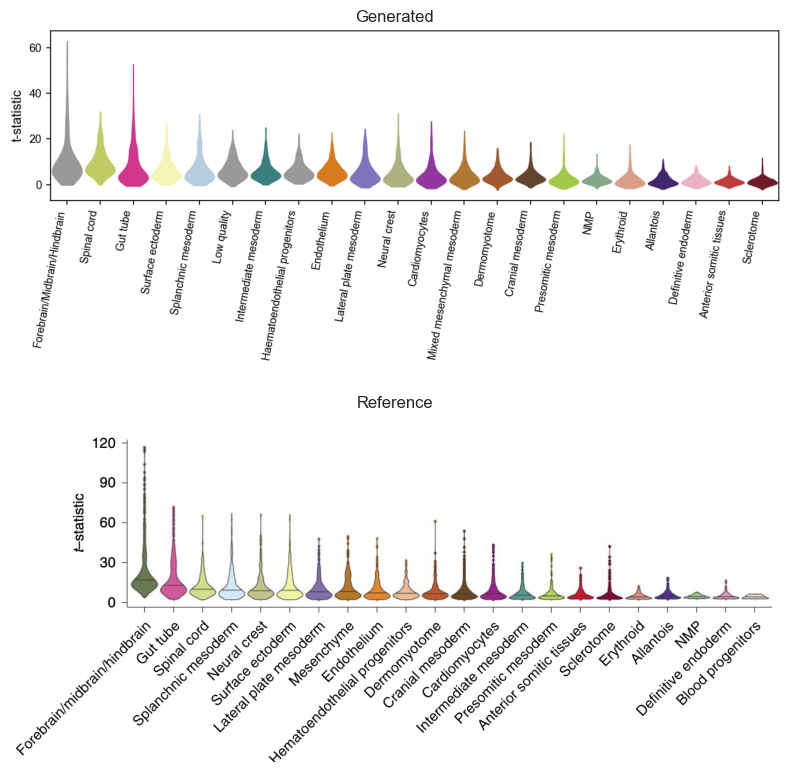

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

generated = mpimg.imread(str(Path.cwd() / f"outputs/{TASK}/figures/violin_lohoff2e.png"))
reference = mpimg.imread(str(data_src_dir / "reference_lohoff-2e.png"))

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].imshow(generated)
axes[0].set_title("Generated")
axes[0].axis("off")

axes[1].imshow(reference)
axes[1].set_title("Reference")
axes[1].axis("off")

plt.tight_layout()
plt.show()